#Isoform Diversity in Senescent Cells

In [ ]:
print("Hello World")

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse, csc_matrix as _csc_matrix
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings, os, sys, gc
warnings.filterwarnings('ignore')
gc.enable()

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from add_classification import add_classification

# Reload pyVolcano so notebook picks up edits without restarting the kernel
import pyVolcano
import importlib
importlib.reload(pyVolcano)
from pyVolcano import plot_volcano, plot_volcano_with_colors

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"

CKPT_DIR = "./../csvs/06_03_diversity_cache"
CKPT_REFRESH = True   # True -> ignore cached CSVs and recompute + overwrite them
os.makedirs(CKPT_DIR, exist_ok=True)

def _ckpt(name):
    """Path to the checkpoint CSV for a named computation."""
    return os.path.join(CKPT_DIR, f"06_03_{name}.csv")

def _ckpt_ok(name):
    """True if a cached CSV exists and we are not force-refreshing."""
    return (not CKPT_REFRESH) and os.path.exists(_ckpt(name))

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


In [2]:
# preferred plot formatting
import matplotlib
import matplotlib.legend as _mlegend
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0

plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.labelspacing": 0.1,
    "legend.borderpad": 0.3,
    "legend.handletextpad": 0.2,
    "legend.title_fontsize": 6,
    "figure.titlesize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD,
    "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
    "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Legend-title weight has no rcParam -> make every legend title bold by default.
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True


#1. Load pre-computed isofrac h5ad, add cell types, tissue, and SQANTI3 classification

In [3]:
# Load the pre-computed isofrac h5ad (already filtered to >=10 cells, >=2 isoforms per gene,
# with isoform_fraction layer)
adata = sc.read_h5ad(f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_ensemblids_bc_anndata_preprocessed_with_isofrac_xgen_cdkn2a.h5ad")
print(f"Loaded: {adata.shape[0]} cells x {adata.shape[1]} isoforms")
print(f"Obs columns: {list(adata.obs.columns)}")
print(f"Var columns: {list(adata.var.columns)}")
print(f"Layers: {list(adata.layers.keys())}")

Loaded: 155117 cells x 478192 isoforms
Obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'tube_id', 'n_counts', 'donor', 'tissue', 'tube_label', 'LR_library_id', 'SR_sample_id', 'popv_prediction', 'popv_prediction_score', 'cell_ontology_class', 'broad_cell_class', 'xgen_matched', 'xgen_cdkn2a_raw', 'xgen_p16_raw', 'xgen_p14ARF_raw', 'xgen_other_cdkn2a_raw', 'xgen_cdkn2a_umi', 'xgen_p16_umi', 'xgen_p14ARF_umi', 'xgen_other_cdkn2a_umi', 'xgen_cdkn2a_umi_cutoff', 'xgen_cdkn2a_raw_pos', 'xgen_cdkn2a_umi_pos', 'xgen_cdkn2a_raw_status', 'xgen_cdkn2a_umi_status']
Var columns: ['transcript_id', 'gene_name', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts']
Layers: ['isoform_fraction']


### p16 vs p14ARF per-cell counts (PacBio / xGen CDKN2A pulldown)

Scatter of each cell's p16 and p14ARF counts (`xgen_p16_raw` vs `xgen_p14ARF_raw`, from the xGen CDKN2A pulldown transferred onto the PacBio cells) on a symlog scale so zero-count cells still appear at the axes. Plotted here before the p14ARF+/other cells are dropped below, so it shows the full population.

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


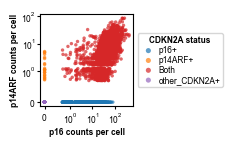

cells: 155117 | p16>0: 3134 | p14ARF>0: 2588 | both>0: 2565


In [4]:
# Per-cell p16 vs p14ARF counts on a (sym)log scale, across all PacBio cells.
import matplotlib.patches as mpatches
P16_COL, P14_COL = "xgen_p16_raw", "xgen_p14ARF_raw"   # raw pigeon-matrix counts; *_umi = distinct-UMI variant
assert P16_COL in adata.obs.columns and P14_COL in adata.obs.columns, "xgen p16/p14ARF count columns not in obs"

p16 = pd.to_numeric(adata.obs[P16_COL], errors="coerce").fillna(0).to_numpy(float)
p14 = pd.to_numeric(adata.obs[P14_COL], errors="coerce").fillna(0).to_numpy(float)
status = (adata.obs["xgen_cdkn2a_raw_status"].astype(str).to_numpy()
          if "xgen_cdkn2a_raw_status" in adata.obs.columns
          else np.where((p16>0)&(p14>0), "Both", np.where(p16>0, "p16+", np.where(p14>0, "p14ARF+", "CDKN2A-"))))

# jitter integer counts a little (nonzero only) so overlapping points are visible on symlog
rng = np.random.default_rng(0)
jx = p16 + rng.uniform(-0.3, 0.3, p16.size) * (p16 > 0)
jy = p14 + rng.uniform(-0.3, 0.3, p14.size) * (p14 > 0)

# Palette matched to the reference-isoform panel in 06_01 so that p16 and
# p14ARF carry the SAME colour in both figures. 06_01 does not hard-code these:
# it falls back to matplotlib tab10 indexed by sorted label, which yields
#     "P42771 (p16INK4a)" -> tab10[0] #1f77b4
#     "Q8N726 (p14ARF)"   -> tab10[1] #ff7f0e
#     "No protein"        -> 0.7
# The coupling is therefore by CONVENTION, not by code. If a third protein
# label ever enters 06_01's reference set the positional assignment shifts and
# these two hex values must be re-checked against it.
P16_HEX, P14_HEX = "#1f77b4", "#ff7f0e"
cmap = {"p16+": P16_HEX,
        "p14ARF+": P14_HEX,
        # no counterpart in 06_01 (which shows only reference proteins); taken
        # from the same tab10 family so the panel reads as one palette
        "Both": "#d62728",
        "other_CDKN2A+": "#9467bd"}
fig, ax = plt.subplots(figsize=(1.2, 1.2))
bg = np.isin(status, ["not_in_pulldown", "CDKN2A-"])
# 06_01 paints "No protein" at 0.7 grey, deliberately NOT matched here: this
# layer carries ~146k points at alpha 0.4 and at 0.7 it would swamp the
# coloured cells rather than sit behind them.
ax.scatter(jx[bg], jy[bg], s=3, c="#dddddd", alpha=0.4, edgecolors="none", rasterized=True)
for st, col in cmap.items():
    m = status == st
    if m.any():
        ax.scatter(jx[m], jy[m], s=6, c=col, alpha=0.7, edgecolors="none", rasterized=True, label=st)
ax.set_xscale("symlog", linthresh=1); ax.set_yscale("symlog", linthresh=1)
ax.set_xlabel("p16 counts per cell"); ax.set_ylabel("p14ARF counts per cell")
n_both = int(((p16>0)&(p14>0)).sum()); n_p16 = int(((p16>0)&(p14==0)).sum()); n_p14 = int(((p14>0)&(p16==0)).sum())
# ax.set_title(f"p16 vs p14ARF per cell (PacBio, symlog)\nboth={n_both}, p16-only={n_p16}, p14ARF-only={n_p14}")
if set(status) & set(cmap):
    ax.legend(loc=6, fontsize=6, 
              title="CDKN2A status", markerscale=1.5, bbox_to_anchor = (1.0, 0.5))
plt.savefig(figpath("06_03_p16_vs_p14ARF_percell_scatter.pdf"), bbox_inches="tight")
plt.show()
print(f"cells: {adata.n_obs} | p16>0: {int((p16>0).sum())} | p14ARF>0: {int((p14>0).sum())} | both>0: {n_both}")


### p16 / p14ARF Venn (xGen CDKN2A pulldown)

Venn diagram of cells expressing p16 (`p16+` or `Both`) versus p14ARF (`p14ARF+` or `Both`), from the xGen CDKN2A pulldown raw status. Shown on the full population, before the `p14ARF+`-only and `other_CDKN2A+` cells are dropped in section 2; the intersection is the `Both` cells.

p16-expressing (p16+ or Both):    3134
p14ARF-expressing (p14ARF+/Both): 2588
  p16 only: 569 | p14ARF only: 23 | Both: 2565
Cells with an identifiable p16/p14ARF transcript: 3157 | both = 2565 (81.2%) | single = 592 (18.8%)
[both vs single] binomial (null p=0.5, greater): 2565/3157 = 81.2%, p = 5.11e-291
[co-occurrence] Fisher 2x2 [[2565,569],[23,5797]]: OR = 1136.2, p = 0.00e+00

Per-donor co-expression (of cells with an identifiable p16/p14ARF transcript):
donor  both  p16_only  p14ARF_only  both_frac
TSP21   217        20            0      0.916
TSP25  1019       255           18      0.789
TSP27   730       156            3      0.821
TSP33   599       138            2      0.811


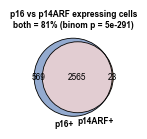

In [6]:
# Venn of p16+ and p14ARF+ cells from the xGen CDKN2A pulldown raw status.
# Full population (before section 2 drops p14ARF+-only / other_CDKN2A+ cells).
from matplotlib_venn import venn2, venn2_circles
from scipy.stats import binomtest, fisher_exact

_st = adata.obs["xgen_cdkn2a_raw_status"].astype(str)
n_p16_only = int((_st == "p16+").sum())
n_p14_only = int((_st == "p14ARF+").sum())
n_both     = int((_st == "Both").sum())
n_pos = n_p16_only + n_p14_only + n_both            # cells with an identifiable p16 or p14ARF transcript
n_single = n_p16_only + n_p14_only
print(f"p16-expressing (p16+ or Both):    {n_p16_only + n_both}")
print(f"p14ARF-expressing (p14ARF+/Both): {n_p14_only + n_both}")
print(f"  p16 only: {n_p16_only} | p14ARF only: {n_p14_only} | Both: {n_both}")
print(f"Cells with an identifiable p16/p14ARF transcript: {n_pos} | "
      f"both = {n_both} ({100*n_both/n_pos:.1f}%) | single = {n_single} ({100*n_single/n_pos:.1f}%)")

# --- Statistics -------------------------------------------------------------
# (1) Do significantly MORE cells express BOTH isoforms than only ONE?
#     Binomial test on cells expressing >=1 isoform; null = 50/50 both-vs-single.
bt = binomtest(n_both, n_pos, 0.5, alternative="greater")
print(f"[both vs single] binomial (null p=0.5, greater): {n_both}/{n_pos} = {100*n_both/n_pos:.1f}%, p = {bt.pvalue:.2e}")

# (2) Do p16 and p14ARF CO-OCCUR beyond chance? Fisher exact on the 2x2 over
#     pulldown-called cells; "neither" = other_CDKN2A+ / CDKN2A- called cells (p16- & p14-).
n_neither = int(_st.isin(["other_CDKN2A+", "CDKN2A-"]).sum())
OR, fp = fisher_exact([[n_both, n_p16_only], [n_p14_only, n_neither]], alternative="greater")
print(f"[co-occurrence] Fisher 2x2 [[{n_both},{n_p16_only}],[{n_p14_only},{n_neither}]]: OR = {OR:.1f}, p = {fp:.2e}")

# (3) Per-donor both-fraction (co-expression is high in most donors, lower in one).
if "donor" in adata.obs.columns:
    _pdf = adata.obs.assign(_s=_st.values)
    rows = []
    for d, g in _pdf.groupby("donor"):
        s = g["_s"]
        b = int((s == "Both").sum()); o1 = int((s == "p16+").sum()); o2 = int((s == "p14ARF+").sum())
        tot = b + o1 + o2
        if tot > 0:
            rows.append({"donor": d, "both": b, "p16_only": o1, "p14ARF_only": o2, "both_frac": b / tot})
    print("\nPer-donor co-expression (of cells with an identifiable p16/p14ARF transcript):")
    print(pd.DataFrame(rows).round(3).to_string(index=False))

# --- Venn plot --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(1.2, 1.2))
v = venn2(subsets=(n_p16_only, n_p14_only, n_both),
          set_labels=("p16+", "p14ARF+"),
          set_colors=("#4c72b0", "#dd8452"), alpha=0.6, ax=ax)
venn2_circles(subsets=(n_p16_only, n_p14_only, n_both), linewidth=0.6, ax=ax)
for t in list(v.set_labels) + list(v.subset_labels):
    if t is not None:
        t.set_fontsize(6)
for t in v.set_labels:
    if t is not None:
        t.set_fontweight("bold")
ax.set_title(f"p16 vs p14ARF expressing cells\nboth = {100*n_both/n_pos:.0f}% (binom p = {bt.pvalue:.0e})",
             pad=PANEL_TITLE_PAD)
fig.savefig(figpath("06_03_p16_p14ARF_venn.pdf"))
plt.show()

### CDKN2A+ cells per donor: PacBio whole-cell expression vs xGen pulldown call

Two independent labellings of the *same* cells, counted per donor:

- **PacBio** — CDKN2A detected in this object's own counts (`adata.X`, features whose `gene_name` is CDKN2A). This is what the whole-cell library sees unaided.
- **xGen** — `xgen_cdkn2a_raw_status` from the targeted capture, i.e. the RAW pigeon-matrix call.

They are expected to disagree, and by a lot: the pulldown concentrates CDKN2A molecules roughly 10⁴-fold (06_18), so it detects the gene in many cells where the whole-cell library reads zero. The gap between the two bars is the reason the pulldown exists.

**This cell must run before the CDKN2A classification section below**, which drops `p14ARF+`-only and `other_CDKN2A+` cells. Those are xGen-positive, so counting after the drop would understate the xGen bar by construction.

Two caveats on the numbers. The PacBio side is computed on the **isofrac-filtered** object (isoforms in ≥10 cells, genes with ≥2 isoforms), not the raw atlas, so it is a floor. And the xGen side uses the **raw** matrix call, whose counts `groupdedup` inflates in a depth-driven way — `xgen_cdkn2a_umi_status` is the distinct-UMI alternative and is the more conservative choice.

CDKN2A features in this (isofrac-filtered) object: 26
PacBio call: CDKN2A counts >= 1   |   xGen call: raw status in ('p16+', 'p14ARF+', 'Both', 'other_CDKN2A+')

       n_cells  pacbio_CDKN2A+  xgen_raw_CDKN2A+  both  pct_pacbio  pct_xgen  xgen/pacbio
donor                                                                                    
TSP21    21211             472               253   142        2.23      1.19         0.54
TSP25    21201            1923              2054  1159        9.07      9.69         1.07
TSP27    50618            1258               917   368        2.49      1.81         0.73
TSP33    62087            1524               845   403        2.45      1.36         0.55

xGen status breakdown (all donors):
not_in_pulldown    146163
CDKN2A-              4885
Both                 2565
other_CDKN2A+         912
p16+                  569
p14ARF+                23

concordance across all donors: PacBio+ 5,177 | xGen+ 4,069 | both 2,072
  of PacBio-positive cells, 40.

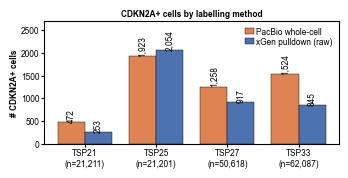


wrote csvs/06_03_cdkn2a_pos_pacbio_vs_xgen_by_donor.csv


In [7]:
# CDKN2A+ cells per donor under two independent labellings. MUST run before the CDKN2A
# classification cell below, which drops p14ARF+ / other_CDKN2A+ (both xGen-positive).
PACBIO_CDKN2A_MIN = 1                                    # whole-cell counts to call CDKN2A+
XGEN_POS = ("p16+", "p14ARF+", "Both", "other_CDKN2A+")  # every xGen-positive category

# SQANTI associated_gene holds ENSG ids, so match on gene_name.
_gn = adata.var["gene_name"].astype(str).values
_cd = np.where(_gn == "CDKN2A")[0]
if _cd.size == 0:
    raise ValueError("no feature with gene_name == 'CDKN2A' in adata.var")
_Xc = adata.X[:, _cd]
_pb_counts = (np.asarray(_Xc.sum(axis=1)).ravel() if issparse(_Xc)
              else np.asarray(_Xc).sum(axis=1))
_pb_pos = _pb_counts >= PACBIO_CDKN2A_MIN

_status = adata.obs["xgen_cdkn2a_raw_status"].astype(str).values
_xg_pos = np.isin(_status, XGEN_POS)
_donor = adata.obs["donor"].astype(str).values
_donors = sorted(pd.unique(_donor))

cd_tab = pd.DataFrame({
    "n_cells": [int((_donor == d).sum()) for d in _donors],
    "pacbio_CDKN2A+": [int((_pb_pos & (_donor == d)).sum()) for d in _donors],
    "xgen_raw_CDKN2A+": [int((_xg_pos & (_donor == d)).sum()) for d in _donors],
    "both": [int((_pb_pos & _xg_pos & (_donor == d)).sum()) for d in _donors],
}, index=pd.Index(_donors, name="donor"))
cd_tab["pct_pacbio"] = 100 * cd_tab["pacbio_CDKN2A+"] / cd_tab["n_cells"]
cd_tab["pct_xgen"] = 100 * cd_tab["xgen_raw_CDKN2A+"] / cd_tab["n_cells"]
cd_tab["xgen/pacbio"] = cd_tab["xgen_raw_CDKN2A+"] / cd_tab["pacbio_CDKN2A+"].replace(0, np.nan)

print(f"CDKN2A features in this (isofrac-filtered) object: {_cd.size}")
print(f"PacBio call: CDKN2A counts >= {PACBIO_CDKN2A_MIN}   |   xGen call: raw status in {XGEN_POS}")
print()
print(cd_tab.to_string(float_format=lambda v: f"{v:.2f}"))
print()
print("xGen status breakdown (all donors):")
print(pd.Series(_status).value_counts().to_string())
print()
_ov = int((_pb_pos & _xg_pos).sum())
print(f"concordance across all donors: PacBio+ {int(_pb_pos.sum()):,} | xGen+ "
      f"{int(_xg_pos.sum()):,} | both {_ov:,}")
print(f"  of PacBio-positive cells, {100 * _ov / max(int(_pb_pos.sum()), 1):.1f}% are also xGen-positive")
print(f"  of xGen-positive cells,   {100 * _ov / max(int(_xg_pos.sum()), 1):.1f}% are also PacBio-positive")

fig, ax = plt.subplots(figsize=(max(2.4, 0.7 * len(_donors) + 1.0), 1.6))
_x = np.arange(len(_donors)); _w = 0.38
_b1 = ax.bar(_x - _w / 2, cd_tab["pacbio_CDKN2A+"], _w, label="PacBio whole-cell",
             color="#dd8452", edgecolor="black", linewidth=0.3)
_b2 = ax.bar(_x + _w / 2, cd_tab["xgen_raw_CDKN2A+"], _w, label="xGen pulldown (raw)",
             color="#4c72b0", edgecolor="black", linewidth=0.3)
for _bars in (_b1, _b2):
    for _r in _bars:
        ax.text(_r.get_x() + _r.get_width() / 2, _r.get_height(),
                f"{int(_r.get_height()):,}", ha="center", va="bottom", rotation=90)
ax.set_xticks(_x)
ax.set_xticklabels([f"{d}\n(n={cd_tab.loc[d, 'n_cells']:,})" for d in _donors])
ax.set_ylabel("# CDKN2A+ cells")
ax.set_title("CDKN2A+ cells by labelling method", pad=PANEL_TITLE_PAD)
ax.set_ylim(0, float(cd_tab[["pacbio_CDKN2A+", "xgen_raw_CDKN2A+"]].values.max()) * 1.32)
ax.legend(frameon=False, handlelength=1.0, handletextpad=0.3)
ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
fig.savefig(figpath("06_03_cdkn2a_pos_pacbio_vs_xgen_by_donor.pdf"),
            bbox_inches="tight", dpi=300)
plt.show()
cd_tab.to_csv("./../csvs/06_03_cdkn2a_pos_pacbio_vs_xgen_by_donor.csv")
print("\nwrote csvs/06_03_cdkn2a_pos_pacbio_vs_xgen_by_donor.csv")

### CDKN2A molecule enrichment: pulldown vs whole-cell, per donor

The molecule-level counterpart to the cell-count panel above, and the one that actually supports a *coverage* claim.

06_18 reports two enrichment figures for T73/TSP33: CDKN2A share of all UMIs (90,255×) and **mean CDKN2A molecules per cell** (29.73 vs 0.031). Only the second is computable here — this object carries per-cell xGen CDKN2A counts but not the pulldown's total UMIs, so the share denominator is unavailable. The per-cell form is the more directly interpretable of the two anyway: it says how many CDKN2A molecules each assay recovers from the same cell.

**Restricted to pulldown-measured cells** (`xgen_cdkn2a_raw_status != 'not_in_pulldown'`). For never-measured barcodes the xGen count is zero by *absence*, not by measurement, so including them would deflate the pulldown mean and understate enrichment — the opposite of the cell-count panel's problem, where the same cells inflate the whole-cell side.

Both xGen count columns are tabulated. **`xgen_cdkn2a_umi` (distinct UMIs) is plotted by default**; `xgen_cdkn2a_raw` carries the ~14.6× `groupdedup` over-split inflation and will report a correspondingly larger enrichment. Quote the UMI number.

CDKN2A molecules per cell, pulldown-measured cells only (8,954 of 155,117)
plotted xGen column: xgen_cdkn2a_umi

       n_measured  xgen_umi_per_cell  xgen_raw_per_cell  pacbio_per_cell  fold_umi  fold_raw
donor                                                                                       
TSP21         375              4.085             50.107            1.197     3.412    41.849
TSP25        2261              7.913            132.201            0.914     8.656   144.609
TSP27        4577              0.806             11.194            0.146     5.529    76.817
TSP33        1741              2.180             32.966            0.445     4.897    74.057

raw/UMI ratio per donor (the groupdedup over-split factor): TSP21=12.3x, TSP25=16.7x, TSP27=13.9x, TSP33=15.1x


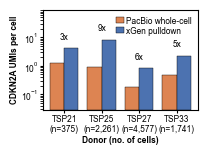


wrote csvs/06_03_cdkn2a_molecule_enrichment_by_donor.csv


In [11]:
# CDKN2A molecules per cell: xGen pulldown vs PacBio whole-cell, per donor.
# Restricted to pulldown-MEASURED cells: a not_in_pulldown barcode has an xGen count of zero
# because it was never assayed, and averaging those in would understate the enrichment.
XGEN_COUNT_COL = "xgen_cdkn2a_umi"    # distinct UMIs -- the defensible column.
                                      # "xgen_cdkn2a_raw" carries the ~14.6x groupdedup inflation.
for _c in (XGEN_COUNT_COL, "xgen_cdkn2a_raw", "xgen_cdkn2a_raw_status"):
    assert _c in adata.obs.columns, f"{_c} not in adata.obs"

_gn2 = adata.var["gene_name"].astype(str).values
_cd2 = np.where(_gn2 == "CDKN2A")[0]
_Xc2 = adata.X[:, _cd2]
_pb_cd = (np.asarray(_Xc2.sum(axis=1)).ravel() if issparse(_Xc2)
          else np.asarray(_Xc2).sum(axis=1))
_st2 = adata.obs["xgen_cdkn2a_raw_status"].astype(str).values
_meas = _st2 != "not_in_pulldown"
_dn2 = adata.obs["donor"].astype(str).values
_don2 = sorted(pd.unique(_dn2))
_xg_umi = pd.to_numeric(adata.obs[XGEN_COUNT_COL], errors="coerce").fillna(0).to_numpy(float)
_xg_raw = pd.to_numeric(adata.obs["xgen_cdkn2a_raw"], errors="coerce").fillna(0).to_numpy(float)

_rows = []
for _d in _don2:
    _m = _meas & (_dn2 == _d)
    _rows.append({
        "donor": _d, "n_measured": int(_m.sum()),
        "xgen_umi_per_cell": float(_xg_umi[_m].mean()) if _m.any() else np.nan,
        "xgen_raw_per_cell": float(_xg_raw[_m].mean()) if _m.any() else np.nan,
        "pacbio_per_cell": float(_pb_cd[_m].mean()) if _m.any() else np.nan,
    })
enr = pd.DataFrame(_rows).set_index("donor")
enr["fold_umi"] = enr["xgen_umi_per_cell"] / enr["pacbio_per_cell"].replace(0, np.nan)
enr["fold_raw"] = enr["xgen_raw_per_cell"] / enr["pacbio_per_cell"].replace(0, np.nan)

print(f"CDKN2A molecules per cell, pulldown-measured cells only "
      f"({int(_meas.sum()):,} of {len(_meas):,})")
print(f"plotted xGen column: {XGEN_COUNT_COL}")
print()
print(enr.to_string(float_format=lambda v: f"{v:,.3f}"))
print()
print(f"raw/UMI ratio per donor (the groupdedup over-split factor): "
      + ", ".join(f"{d}={enr.loc[d, 'xgen_raw_per_cell'] / max(enr.loc[d, 'xgen_umi_per_cell'], 1e-12):.1f}x"
                  for d in _don2))

fig, ax = plt.subplots(figsize=(2.0, 1.3))
_x2 = np.arange(len(_don2)); _w2 = 0.38
_lo = float(np.nanmin(enr["pacbio_per_cell"].replace(0, np.nan)))
_bot = max(_lo / 5, 1e-4)
ax.bar(_x2 - _w2 / 2, enr["pacbio_per_cell"], _w2, bottom=_bot,
       label="PacBio whole-cell", color="#dd8452", edgecolor="black", linewidth=0.3)
ax.bar(_x2 + _w2 / 2, enr["xgen_umi_per_cell"], _w2, bottom=_bot,
       label="xGen pulldown", color="#4c72b0", edgecolor="black", linewidth=0.3)
ax.set_yscale("log")
ax.set_ylim(_bot, float(enr["xgen_umi_per_cell"].max()) * 12)
for _i, _d in enumerate(_don2):                      # fold change above each pair
    ax.text(_i, float(enr.loc[_d, "xgen_umi_per_cell"]) * 1.8,
            f"{enr.loc[_d, 'fold_umi']:,.0f}x", ha="center", va="bottom")
ax.set_xticks(_x2)
ax.set_xticklabels([f"{d}\n(n={int(enr.loc[d, 'n_measured']):,})" for d in _don2])
ax.set_ylabel("CDKN2A UMIs per cell")
ax.set_xlabel("Donor (no. of cells)")

# ax.set_title("CDKN2A molecule enrichment in the targeted pulldown", pad=PANEL_TITLE_PAD)
ax.legend(frameon=False, handlelength=1.0, handletextpad=0.2, loc="upper right")
ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
fig.savefig(figpath("06_03_cdkn2a_molecule_enrichment_by_donor.pdf"),
            bbox_inches="tight", dpi=300)
plt.show()
enr.to_csv("./../csvs/06_03_cdkn2a_molecule_enrichment_by_donor.csv")
print("\nwrote csvs/06_03_cdkn2a_molecule_enrichment_by_donor.csv")